# AI-Powered Sentiment Analysis System
**Month 2 Project – NLP + Machine Learning (Beginner → Intermediate)**

## 1. Project introduction
**Sentiment analysis** is an NLP task where a computer reads a piece of text and decides what opinion it expresses.
Here the input is a **customer review** and the output is one of three classes: **Positive**, **Negative** or **Neutral**.
This is *supervised multiclass classification*: we show the model many reviews together with the correct label, and it learns which words/phrases go with which label.

**Workflow of this notebook**

`Load → Inspect → Clean → EDA → Preprocess → Split → TF-IDF → Train & compare → Cross-validate → Tune (GridSearchCV) → Choose final model → Test → Save pipeline`

Only traditional NLP + machine learning is used (TF-IDF, Logistic Regression, Naive Bayes, Linear SVM). No deep learning, transformers, LLMs or external APIs.

## 2. Import libraries

In [1]:
import sys, inspect, re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split

# Make the project's `src/` package importable when the notebook is run from notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.preprocessing import (DATA_PATH, TEXT_COL, TARGET_COL, VALID_LABELS,
                               clean_text, clean_dataframe, load_raw_data)
from src.evaluate import (compute_metrics, evaluate_pipeline, plot_confusion_matrix,
                          multiclass_roc_auc, plot_roc)
from src import train as T          # reuse the exact same pipeline / grid definitions as the script

sns.set_theme(style="whitegrid")
RANDOM_STATE = T.RANDOM_STATE
print("Project root:", ROOT)

Project root: /home/claude/sentiment-analysis


## 3. Load the dataset
The CSV is the **source of truth**; nothing about its structure is assumed – we inspect it first.

In [2]:
df_raw = load_raw_data()
print("Loaded from:", DATA_PATH)
df_raw.head(8)

Loaded from: /home/claude/sentiment-analysis/data/reviews.csv


,review_id,review_text,sentiment,category,source
0,1,This product exceeded my expectations in sever...,Positive,Books,Online Store
1,2,The item is uncomfortable to use and poorly de...,Negative,Books,Online Store
2,3,The product comes with a charging adapter and ...,Neutral,Travel,Customer Survey
3,4,Customer support was slow and did not solve my...,Negative,Home & Kitchen,Website
4,5,"The design is simple, attractive, and comforta...",Positive,Sports,Online Store
5,6,The delivery was late and the package arrived ...,Negative,Sports,Website
6,7,This is one of the better purchases I have mad...,Positive,Home & Kitchen,Mobile App
7,8,The product works perfectly and feels well mad...,Positive,Books,Customer Survey


## 4. Dataset inspection

In [3]:
print("Rows, columns:", df_raw.shape)
print("\nColumn names:", list(df_raw.columns))
print("\nData types:\n", df_raw.dtypes)
print("\nMissing values per column:\n", df_raw.isna().sum())
print("\nExact duplicate rows:", df_raw.duplicated().sum())
print("Duplicate review_id values:", df_raw['review_id'].duplicated().sum())

Rows, columns: (10000, 5)

Column names: ['review_id', 'review_text', 'sentiment', 'category', 'source']

Data types:
 review_id      int64
review_text      str
sentiment        str
category         str
source           str
dtype: object

Missing values per column:
 review_id      0
review_text    0
sentiment      0
category       0
source         0
dtype: int64

Exact duplicate rows: 0
Duplicate review_id values: 0


In [4]:
print("Unique sentiment labels:", sorted(df_raw[TARGET_COL].unique()))
print("\nSentiment distribution:\n", df_raw[TARGET_COL].value_counts())
print("\nCategory distribution:\n", df_raw['category'].value_counts())
print("\nSource distribution:\n", df_raw['source'].value_counts())

lengths = df_raw[TEXT_COL].str.len()
words = df_raw[TEXT_COL].str.split().str.len()
print("\nReview length (characters):\n", lengths.describe().round(1))
print("\nReview length (words):\n", words.describe().round(1))
print("\nReviews shorter than 3 words:", (words < 3).sum(), "| empty reviews:", (lengths == 0).sum())
print("Reviews containing URLs:", df_raw[TEXT_COL].str.contains(r"http|www", case=False).sum())
print("Reviews with non-ASCII characters:", df_raw[TEXT_COL].str.contains(r"[^\x00-\x7F]").sum())

Unique sentiment labels: ['Negative', 'Neutral', 'Positive']

Sentiment distribution:
 sentiment
Positive    3334
Negative    3333
Neutral     3333
Name: count, dtype: int64

Category distribution:
 category
Travel            1305
Clothing          1288
Sports            1278
Beauty            1272
Home & Kitchen    1245
Electronics       1239
Food & Grocery    1205
Books             1168
Name: count, dtype: int64

Source distribution:
 source
Online Store       2590
Customer Survey    2495
Website            2478
Mobile App         2437
Name: count, dtype: int64

Review length (characters):
 count    10000.0
mean        94.6
std         21.7
min         43.0
25%         84.0
50%         99.0
75%        109.0
max        136.0
Name: review_text, dtype: float64

Review length (words):
 count    10000.0
mean        16.3
std          3.9
min          7.0
25%         15.0
50%         17.0
75%         19.0
max         25.0
Name: review_text, dtype: float64

Reviews shorter than 3 words: 0 | 

In [5]:
# The most important discovery about this dataset:
n_unique = df_raw[TEXT_COL].nunique()
print(f"Total reviews: {len(df_raw)}  |  UNIQUE review texts: {n_unique}")
print(f"Each unique text appears {len(df_raw)/n_unique:.1f} times on average "
      f"(min {df_raw[TEXT_COL].value_counts().min()}, max {df_raw[TEXT_COL].value_counts().max()}).")
conflict = (df_raw.groupby(TEXT_COL)[TARGET_COL].nunique() > 1).sum()
print("Texts that appear with MORE THAN ONE sentiment label:", conflict)

Total reviews: 10000  |  UNIQUE review texts: 300
Each unique text appears 33.3 times on average (min 21, max 52).
Texts that appear with MORE THAN ONE sentiment label: 0


### Which columns are used for modelling, and why?

| Column | Use | Reason |
|---|---|---|
| `review_text` | **Feature (input)** | Contains the opinion itself – the only thing available for a *new* review typed in the app. |
| `sentiment` | **Target (label)** | What we want to predict. |
| `review_id` | Not used | A row counter with no meaning; it could only let the model memorise rows. |
| `category`, `source` | Not used for modelling | Used in EDA only. A new review in the app has no category/source, and the labels look balanced across them (see EDA), so they would add complexity without helping. |

Using `sentiment` in any feature would be **data leakage** (the answer leaking into the input), so it is excluded.

### ⚠️ Key finding: the dataset has only 300 unique reviews
The 10,000 rows are the same 300 sentences repeated with different ids, categories and sources. No text has conflicting labels, so the labels are consistent, but this creates a serious **data-leakage risk** when splitting into train and test. Sections 5 and 8 deal with this.

## 5. Data cleaning
`clean_dataframe()` (in `src/preprocessing.py`) does the cleaning and returns a report of what each step removed:
missing values → consistent label spelling → empty text → exact duplicate rows → duplicate ids → duplicate texts.

In [6]:
df_all, report_all = clean_dataframe(df_raw, deduplicate_text=False)   # keep all 10,000 rows for EDA
pd.Series(report_all, name="value").to_frame()

,value
rows_raw,10000
missing_review_text,0
missing_sentiment,0
invalid_labels_removed,0
empty_reviews_removed,0
duplicate_rows,0
duplicate_review_ids,0
rows_after_basic_cleaning,10000
duplicate_texts,9700
texts_with_conflicting_labels,0


Nothing needed fixing in the basic checks (no missing values, no invalid labels, no duplicate rows or ids), so no rows were dropped there. The only issue is **duplicate texts** (9,700 repeats).

### Why duplicate texts matter – a demonstration
If we split all 10,000 rows randomly, the *same sentence* will land in both train and test. The test score then measures **memorisation**, not generalisation. Below is a *demonstration only* (this naive split is not used for any real decision).

In [7]:
Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(df_all[TEXT_COL], df_all[TARGET_COL], test_size=0.2,
                                              stratify=df_all[TARGET_COL], random_state=RANDOM_STATE)
share = Xn_te.isin(set(Xn_tr)).mean()
print(f"Naive split: {share:.1%} of the 'unseen' test reviews are word-for-word copies of training reviews.")
demo = T.make_pipeline(LogisticRegression(max_iter=1000)).fit(Xn_tr, yn_tr)
print("Naive-split accuracy (inflated by copies):", round(demo.score(Xn_te, yn_te), 4))

Naive split: 100.0% of the 'unseen' test reviews are word-for-word copies of training reviews.


Naive-split accuracy (inflated by copies): 1.0


**Decision:** for modelling we keep **one row per unique review text** (300 rows). Train and test then contain *different* texts, and cross-validation folds do too. The 10,000-row version is still used for EDA (class balance, lengths, categories).

In [8]:
df, report = clean_dataframe(df_raw, deduplicate_text=True)
print("Rows used for modelling:", len(df))
print(df[TARGET_COL].value_counts())

Rows used for modelling: 300
sentiment
Positive    100
Negative    100
Neutral     100
Name: count, dtype: int64


## 6. Exploratory Data Analysis (EDA)
EDA charts use the cleaned 10,000-row data (`df_all`) unless stated otherwise.

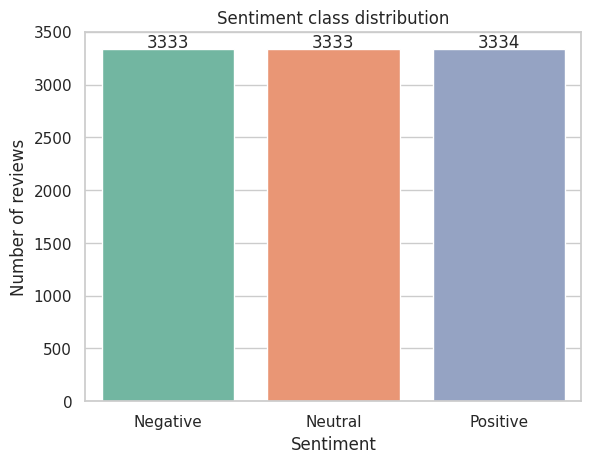

In [9]:
order = VALID_LABELS
counts = df_all[TARGET_COL].value_counts().reindex(order)
ax = sns.barplot(x=counts.index, y=counts.values, order=order, hue=counts.index, palette="Set2", legend=False)
for i, v in enumerate(counts.values):
    ax.text(i, v + 20, str(v), ha="center")
ax.set_title("Sentiment class distribution"); ax.set_xlabel("Sentiment"); ax.set_ylabel("Number of reviews")
plt.show()

**Interpretation:** the three classes are almost perfectly balanced (~3,333 each). Accuracy is therefore a fair metric, and no resampling or class weighting is needed. Macro-averaged precision/recall/F1 are still reported so each class counts equally.

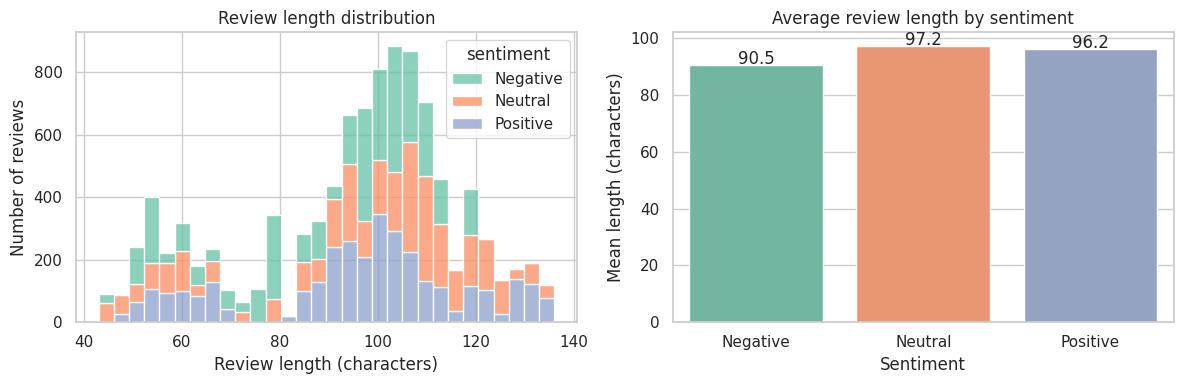

In [10]:
df_all["n_chars"] = df_all[TEXT_COL].str.len()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_all, x="n_chars", hue=TARGET_COL, hue_order=order, bins=30, multiple="stack", ax=axes[0], palette="Set2")
axes[0].set_title("Review length distribution"); axes[0].set_xlabel("Review length (characters)"); axes[0].set_ylabel("Number of reviews")
avg = df_all.groupby(TARGET_COL)["n_chars"].mean().reindex(order)
sns.barplot(x=avg.index, y=avg.values, order=order, hue=avg.index, palette="Set2", legend=False, ax=axes[1])
for i, v in enumerate(avg.values): axes[1].text(i, v + 0.5, f"{v:.1f}", ha="center")
axes[1].set_title("Average review length by sentiment"); axes[1].set_xlabel("Sentiment"); axes[1].set_ylabel("Mean length (characters)")
plt.tight_layout(); plt.show()

**Interpretation:** reviews are short (roughly 43–136 characters). Negative reviews are a little shorter on average than Positive/Neutral ones, but the distributions overlap heavily, so length alone cannot separate the classes. The *words* must carry the signal, which justifies a text-feature approach.

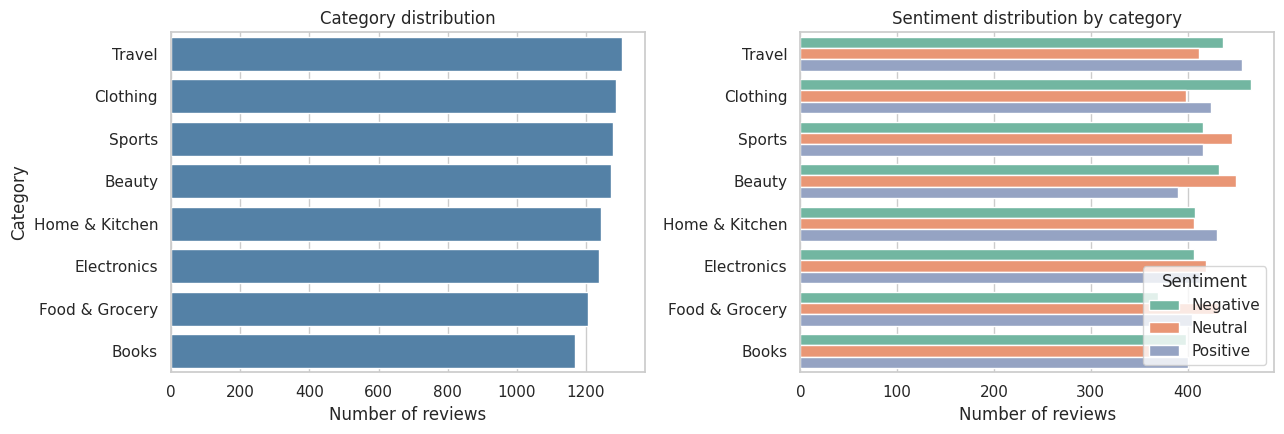

sentiment       Negative  Neutral  Positive
category                                   
Beauty             0.340    0.354     0.307
Books              0.341    0.317     0.342
Clothing           0.362    0.309     0.329
Electronics        0.328    0.338     0.333
Food & Grocery     0.306    0.358     0.336
Home & Kitchen     0.328    0.327     0.345
Sports             0.326    0.349     0.326
Travel             0.335    0.316     0.349


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
cat_order = df_all["category"].value_counts().index
sns.countplot(data=df_all, y="category", order=cat_order, color="steelblue", ax=axes[0])
axes[0].set_title("Category distribution"); axes[0].set_xlabel("Number of reviews"); axes[0].set_ylabel("Category")
sns.countplot(data=df_all, y="category", hue=TARGET_COL, hue_order=order, order=cat_order, palette="Set2", ax=axes[1])
axes[1].set_title("Sentiment distribution by category"); axes[1].set_xlabel("Number of reviews"); axes[1].set_ylabel("")
axes[1].legend(title="Sentiment", loc="lower right")
plt.tight_layout(); plt.show()
print(pd.crosstab(df_all["category"], df_all[TARGET_COL], normalize="index").round(3))

**Interpretation:** the eight categories are similarly sized and each has a roughly one-third mix of the three sentiments (table above). Category therefore tells us almost nothing about sentiment, which supports leaving it out of the model.

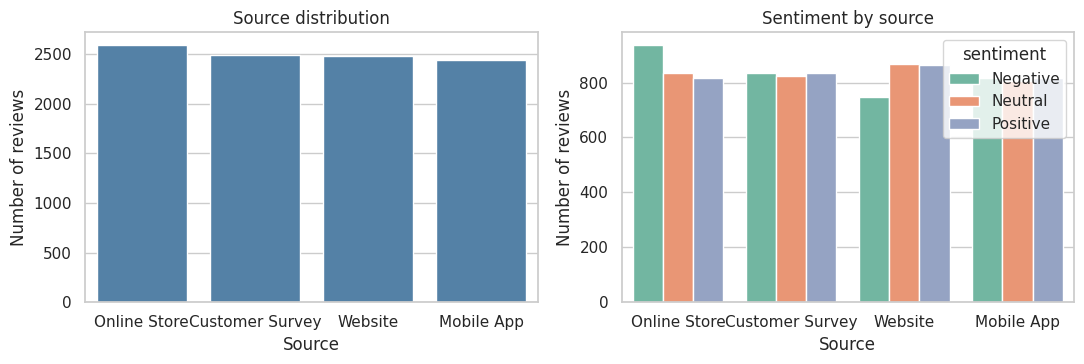

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
sns.countplot(data=df_all, x="source", order=df_all["source"].value_counts().index, color="steelblue", ax=axes[0])
axes[0].set_title("Source distribution"); axes[0].set_xlabel("Source"); axes[0].set_ylabel("Number of reviews")
sns.countplot(data=df_all, x="source", hue=TARGET_COL, hue_order=order, palette="Set2", ax=axes[1])
axes[1].set_title("Sentiment by source"); axes[1].set_xlabel("Source"); axes[1].set_ylabel("Number of reviews")
plt.tight_layout(); plt.show()

**Interpretation:** the four sources are also evenly spread and balanced across sentiments, so `source` is not informative for prediction either.

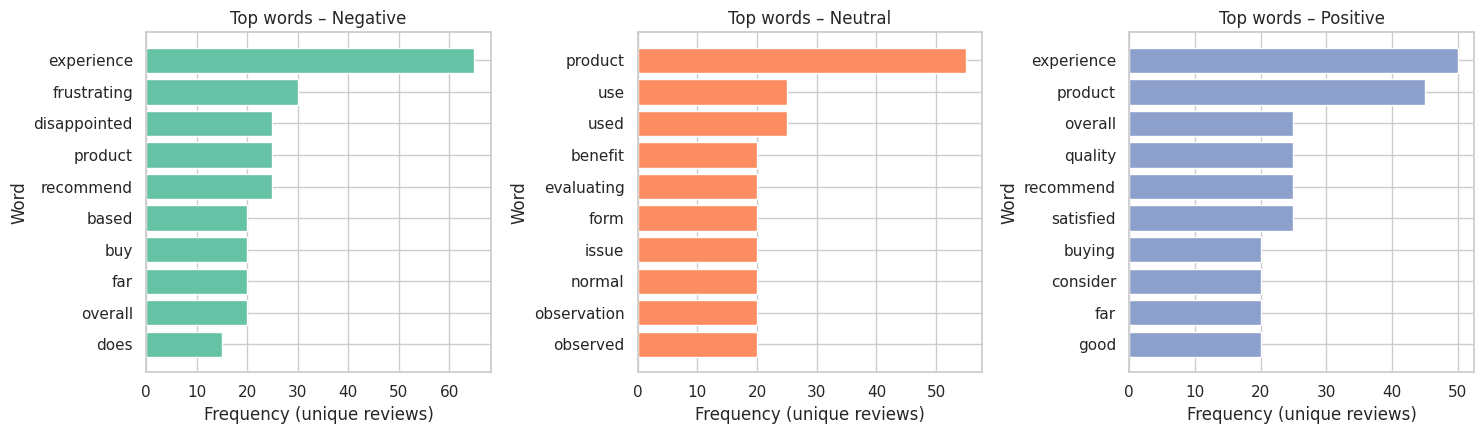

In [13]:
# Most frequent words per sentiment (computed on the 300 UNIQUE texts so repeats don't distort counts)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, lab in zip(axes, order):
    cv = CountVectorizer(preprocessor=clean_text, token_pattern=r"[a-z0-9']+", stop_words="english")
    m = cv.fit_transform(df.loc[df[TARGET_COL] == lab, TEXT_COL])
    freq = pd.Series(np.asarray(m.sum(axis=0)).ravel(), index=cv.get_feature_names_out()).nlargest(10)[::-1]
    ax.barh(freq.index, freq.values, color=sns.color_palette("Set2")[order.index(lab)])
    ax.set_title(f"Top words – {lab}"); ax.set_xlabel("Frequency (unique reviews)"); ax.set_ylabel("Word")
plt.tight_layout(); plt.show()

**Interpretation:** each class has its own vocabulary – Negative reviews use words such as *frustrating* and *disappointed*, Positive ones *satisfied*, *quality* and *good*, and Neutral ones observation-style words (*evaluating, observed, observation, normal, benefit, issue*). Some words (*experience, product, recommend, overall*) appear in several classes, e.g. *recommend* occurs in both 'would recommend' and 'would not recommend', which shows why word context (negation) matters. (Stop-words were hidden **only in this chart** for readability; they are not removed from the model – see section 7.) This is exactly the kind of signal Bag-of-Words/TF-IDF can capture.

## 7. Text preprocessing
Machines cannot read raw sentences, so we first normalise them. The function `clean_text()` (in `src/preprocessing.py`) applies only steps that have a reason:

| Step | Why it is used | Possible drawback |
|---|---|---|
| Lowercase | "Great" and "great" should be one feature | Loses emphasis such as "GREAT" |
| Remove URLs | Links carry no sentiment | None here (no URLs in this data) |
| Punctuation → space (**apostrophes kept**) | Removes noise such as `!!!` and `,` while keeping *don't*, *wasn't* | "!!!" can signal strong emotion, which is lost |
| Collapse whitespace | Avoids empty tokens | None |

**Deliberately NOT applied**

* **Stop-word removal** – standard stop-word lists contain *not, no, never, don't*. Deleting them turns "not good" into "good" and **flips the sentiment**. (Verified in section 9.)
* **Stemming / lemmatization** – they merge word forms (*disappointed → disappoint*). On short, simple reviews the vocabulary is already small, so the gain is negligible while stemming can create odd tokens. We only add it if experiments prove it helps.

The cleaning runs **inside the TF-IDF vectorizer** (`preprocessor=clean_text`), so it is automatically applied to every new review in the app.

In [14]:
examples = ["The delivery was LATE and the package arrived damaged!!!",
            "I don't like it... NOT worth it :( see https://example.com/deal",
            "Excellent   quality,   would buy   again."]
pd.DataFrame({"raw": examples, "cleaned": [clean_text(t) for t in examples]})

,raw,cleaned
0,The delivery was LATE and the package arrived ...,the delivery was late and the package arrived ...
1,I don't like it... NOT worth it :( see https:/...,i don't like it not worth it see
2,"Excellent quality, would buy again.",excellent quality would buy again


## 8. Train / test split
* The **test set** (20 %) is locked away and used **once**, at the very end.
* `stratify=y` keeps the 1/3-1/3-1/3 class balance in both parts.
* `random_state=42` makes the split reproducible.
* All model selection and tuning use **only the training data** (with cross-validation).

In [15]:
X, y = df[TEXT_COL], df[TARGET_COL]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=T.TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
print("Train:", len(X_train), " Test:", len(X_test))
print("Train class counts:", y_train.value_counts().to_dict())
print("Test class counts: ", y_test.value_counts().to_dict())
print("Test texts that also appear in train:", X_test.isin(set(X_train)).sum(), "(must be 0)")

Train: 240  Test: 60
Train class counts: {'Negative': 80, 'Neutral': 80, 'Positive': 80}
Test class counts:  {'Negative': 20, 'Positive': 20, 'Neutral': 20}
Test texts that also appear in train: 0 (must be 0)


In [16]:
# Honest check: how similar are the test reviews to the training reviews at the SENTENCE level?
split_sentences = lambda s: [p.strip() for p in re.split(r"(?<=[.!?])\s+", s) if p.strip()]
train_sents = {p for t in X_train for p in split_sentences(t)}
test_sents = [p for t in X_test for p in split_sentences(t)]
seen = sum(p in train_sents for p in test_sents)
print(f"{seen} of {len(test_sents)} test sentences also appear inside training reviews.")

108 of 108 test sentences also appear inside training reviews.


**Important limitation:** the test *reviews* are new, but every *sentence* in them also occurs in the training reviews, because the dataset was assembled from a small pool of template sentences. Expect very high scores; they show the model learned this dataset's vocabulary, **not** that it would reach the same accuracy on real-world reviews.

## 9. Feature extraction: Bag of Words vs TF-IDF
* **Bag of Words (BoW)** – counts how many times each word appears in a review. Word order is ignored (a "bag" of words).
* **TF-IDF** – *Term Frequency × Inverse Document Frequency*. A word gets a high weight if it is frequent **in this review** (TF) but rare **across all reviews** (IDF). Very common words (e.g. *the*, *is*) get low weight; distinctive words (*disappointed*) get high weight.
* **Why TF-IDF here:** it down-weights filler words automatically (so we do not need stop-word removal), and works well with linear models. BoW is kept as a baseline to check whether TF-IDF really helps.
* **n-grams:** `ngram_range=(1,2)` also uses word pairs such as *"not good"*, which lets a linear model capture short negations.
* **No leakage:** `TfidfVectorizer` is inside the `Pipeline`, so it learns its vocabulary and IDF values only from the training part of each CV fold.

In [17]:
# Tiny toy example so you can SEE what the two representations look like
toy = ["the delivery was late", "the product is great", "the product is not great"]
cnt = CountVectorizer(token_pattern=r"[a-z']+").fit(toy)
tf = TfidfVectorizer(token_pattern=r"[a-z']+").fit(toy)
print("Bag of Words (counts):"); display(pd.DataFrame(cnt.transform(toy).toarray(), columns=cnt.get_feature_names_out(), index=toy))
print("TF-IDF weights:"); display(pd.DataFrame(tf.transform(toy).toarray().round(2), columns=tf.get_feature_names_out(), index=toy))

Bag of Words (counts):


,delivery,great,is,late,not,product,the,was
the delivery was late,1,0,0,1,0,0,1,1
the product is great,0,1,1,0,0,1,1,0
the product is not great,0,1,1,0,1,1,1,0


TF-IDF weights:


,delivery,great,is,late,not,product,the,was
the delivery was late,0.55,0.00,0.00,0.55,0.00,0.00,0.32,0.55
the product is great,0.00,0.53,0.53,0.00,0.00,0.53,0.41,0.00
the product is not great,0.00,0.43,0.43,0.00,0.57,0.43,0.34,0.00


Notice that *the*, *product*, *is* (in many sentences) receive smaller weights than *delivery* or *late* (in one sentence).

In [18]:
print(inspect.getsource(T.make_pipeline))

def make_pipeline(classifier, vectorizer="tfidf") -> Pipeline:
    """Vectorizer + classifier in ONE Pipeline. Because the vectorizer lives inside
    the pipeline, cross-validation re-fits it on each training fold only (no leakage)."""
    if vectorizer == "bow":
        vec = CountVectorizer(preprocessor=clean_text, token_pattern=r"[a-z0-9']+")
    else:
        vec = TfidfVectorizer(preprocessor=clean_text, token_pattern=r"[a-z0-9']+", sublinear_tf=True)
    return Pipeline([("tfidf" if vectorizer != "bow" else "bow", vec), ("clf", classifier)])



### Experiment: does removing stop-words help? (cross-validation on training data only)

In [19]:
cv = StratifiedKFold(n_splits=T.CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
def quick(stop):
    vec = TfidfVectorizer(preprocessor=clean_text, token_pattern=r"[a-z0-9']+", sublinear_tf=True, stop_words=stop)
    from sklearn.pipeline import Pipeline
    p = Pipeline([("tfidf", vec), ("clf", LogisticRegression(max_iter=1000))])
    return cross_val_score(p, X_train, y_train, cv=cv, scoring="f1_macro").mean()
print("CV macro-F1 keeping stop-words (our choice):", round(quick(None), 4))
print("CV macro-F1 removing English stop-words:    ", round(quick("english"), 4))
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
print("Negations inside sklearn's stop-word list:", sorted({"not","no","never","nor","cannot"} & ENGLISH_STOP_WORDS))

CV macro-F1 keeping stop-words (our choice): 0.9875
CV macro-F1 removing English stop-words:     0.9917
Negations inside sklearn's stop-word list: ['cannot', 'never', 'no', 'nor', 'not']


Removing stop-words gave a CV score only marginally different from keeping them (see the two numbers above; the gap is about one review out of 240, i.e. within noise), while the stop-word list contains negations such as *not*, *no* and *never*. Because the benefit is negligible and removing negations is risky for real reviews (e.g. 'not good'), we keep the stop-words.

## 10. Model training
Three classic classifiers are compared, each combined with TF-IDF in one pipeline:

| Model | Idea | Why it is suitable |
|---|---|---|
| **Logistic Regression** | Learns a weight per word; turns a weighted sum into class probabilities | Strong text baseline, gives real probabilities, weights are explainable |
| **Multinomial Naive Bayes** | Uses word-frequency statistics per class and Bayes' rule | Very fast; designed for count/TF-IDF text features |
| **Linear SVM (LinearSVC)** | Finds the widest-margin separating boundary | Often the most accurate linear text model; no native probabilities |

First, **default settings** are compared with 5-fold stratified cross-validation on the training data only.

In [20]:
rows = []
for name, pipe in T.baseline_models().items():
    rows.append({"Model": name, **T.cv_scores(pipe, X_train, y_train, cv)})
baseline_df = pd.DataFrame(rows)
baseline_df.round(4)

,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,BoW + Logistic Regression,0.9875,0.9882,0.9875,0.9875
1,TF-IDF + Logistic Regression,0.9875,0.9880,0.9875,0.9875
2,TF-IDF + Naive Bayes,0.9875,0.9880,0.9875,0.9875
3,TF-IDF + Linear SVM,0.9958,0.9961,0.9958,0.9958


## 11. Model comparison
Metrics are **macro-averaged** for precision, recall and F1: compute each metric for every class, then take the simple average, so all three classes count equally.
These numbers are **validation (cross-validation) scores on the training data**, not test scores.

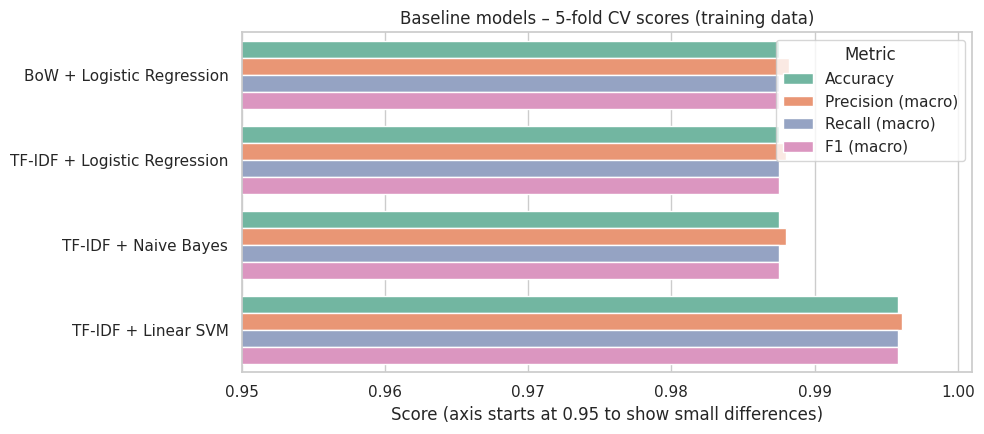

In [21]:
plot_df = baseline_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
plt.figure(figsize=(10, 4.5))
ax = sns.barplot(data=plot_df, y="Model", x="Score", hue="Metric", palette="Set2")
ax.set_xlim(0.95, 1.001); ax.set_title("Baseline models – 5-fold CV scores (training data)")
ax.set_xlabel("Score (axis starts at 0.95 to show small differences)"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

All four combinations are very close to each other (the axis is zoomed in). BoW and TF-IDF perform the same with Logistic Regression on this data. Linear SVM is highest, but its lead over the others is about two reviews out of 240, so the differences between models are very small.

## 12. Cross-validation
**Why?** One train/validation split can be lucky or unlucky. In **stratified 5-fold CV** the training data is cut into 5 parts; each part is used once as validation while the other 4 train the model. We average the 5 scores and also look at their spread. Because the vectorizer is inside the pipeline, it is re-fitted on each fold's training part only – no leakage.

In [22]:
lr_pipe = T.make_pipeline(LogisticRegression(max_iter=1000))
fold_scores = cross_val_score(lr_pipe, X_train, y_train, cv=cv, scoring="f1_macro")
print("Fold macro-F1 scores:", fold_scores.round(4))
print(f"Mean = {fold_scores.mean():.4f}, Std = {fold_scores.std():.4f}")

Fold macro-F1 scores: [0.9791 1.     1.     0.9583 1.    ]
Mean = 0.9875, Std = 0.0167


## 13. Hyperparameter tuning with GridSearchCV
**Hyperparameters** are settings chosen *before* training (e.g. `C`, `alpha`, `ngram_range`). `GridSearchCV` tries every combination in a small grid, scores each with cross-validation, and keeps the best. Only training data is used; the test set is untouched.

Tuned settings (kept small for a student laptop):
* TF-IDF: `ngram_range` (1,1) or (1,2); `min_df` 1 or 2 (ignore very rare terms); `max_df` 0.9 or 1.0 (ignore terms in >90 % of reviews)
* Logistic Regression / Linear SVM: `C` (regularisation strength – smaller = simpler model)
* Naive Bayes: `alpha` (smoothing)
* Scoring: **macro F1**, 5-fold stratified CV. `n_jobs=1` is used on purpose: with only 240 short reviews the search takes seconds, and parallel workers add start-up overhead and can be fragile on Windows.

In [23]:
warnings.filterwarnings("ignore", category=UserWarning)
tuned, rows = {}, []
for name, (clf, clf_grid) in T.TUNING.items():
    grid = {**T.TFIDF_GRID, **clf_grid}
    n_combos = int(np.prod([len(v) for v in grid.values()]))
    gs = GridSearchCV(T.make_pipeline(clf), grid, scoring="f1_macro", cv=cv, n_jobs=1).fit(X_train, y_train)
    tuned[name] = gs
    rows.append({"Model": name, "Combinations": n_combos, "Best CV F1 (macro)": round(gs.best_score_, 4),
                 "Best parameters": gs.best_params_})
tuned_df = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", None)
tuned_df

,Model,Combinations,Best CV F1 (macro),Best parameters
0,Logistic Regression,32,0.9958,"{'clf__C': 1, 'tfidf__max_df': 0.9, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}"
1,Naive Bayes,32,1.0000,"{'clf__alpha': 0.01, 'tfidf__max_df': 0.9, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)}"
2,Linear SVM,32,0.9958,"{'clf__C': 0.1, 'tfidf__max_df': 0.9, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}"


## 14. Final model selection
The rule is decided from **cross-validation on training data only** (never the test set):

1. Take the tuned model with the highest CV macro-F1.
2. If several models are within **0.005** of the best (a difference smaller than one review in the CV folds), treat them as **tied** and prefer the one with **native probabilities and easy explanations**: Logistic Regression > Naive Bayes > Linear SVM.

Probabilities matter because the app must show a real confidence value. Linear SVM has no `predict_proba`; we do not fake it.

In [24]:
best = tuned_df["Best CV F1 (macro)"].max()
tied = tuned_df[tuned_df["Best CV F1 (macro)"] >= best - T.TIE_TOLERANCE]["Model"].tolist()
final_name = next(m for m in T.PREFERENCE if m in tied)
final_pipeline = tuned[final_name].best_estimator_
print("Best CV F1 among tuned models:", round(best, 4))
print("Models tied within tolerance:", tied)
print("Selected final model:", final_name)
print("Its best parameters:", tuned[final_name].best_params_)
print("Its validation (CV) macro-F1:", round(tuned[final_name].best_score_, 4))

Best CV F1 among tuned models: 1.0
Models tied within tolerance: ['Logistic Regression', 'Naive Bayes', 'Linear SVM']
Selected final model: Logistic Regression
Its best parameters: {'clf__C': 1, 'tfidf__max_df': 0.9, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}
Its validation (CV) macro-F1: 0.9958


**Reading the result.** Naive Bayes reached the highest CV F1, Logistic Regression and Linear SVM were slightly lower, but the gaps are tiny (about one review of difference) and not statistically meaningful with only 240 training reviews. Under the rule above, all three are tied, so **Logistic Regression** is chosen because:
* it provides real class probabilities (needed for the confidence score in the app),
* its learned word weights can be inspected and explained,
* it is a standard, stable baseline for TF-IDF text classification.

**Why the others were not chosen:** Linear SVM cannot output probabilities without an extra calibration step that we do not need; Naive Bayes was equally good in practice but its probabilities are usually over-confident and less interpretable. (Any of the three would be defensible here; the choice is a practical one, not a big performance gap.)

## 15. Final evaluation on the untouched test set
This is the **first and only** time the test set is used. Note the difference:
* *Validation performance* = cross-validation scores on training data (used to pick and tune models).
* *Final test performance* = the score on data the model never saw (below).

**Metric meanings (per class, then averaged):**
* **Accuracy** – share of all predictions that are correct.
* **Precision** – of the reviews predicted as class X, how many really are X? (avoids false alarms)
* **Recall** – of the reviews that really are X, how many did we find? (avoids misses)
* **F1-score** – harmonic mean of precision and recall; one balanced number.

In [25]:
result = evaluate_pipeline(final_pipeline, X_test, y_test, VALID_LABELS)
pd.Series(result["metrics"], name="Test set").round(4).to_frame()

,Test set
Accuracy,1.0
Precision (macro),1.0
Recall (macro),1.0
F1 (macro),1.0


In [26]:
print(result["report"])

              precision    recall  f1-score   support

    Negative      1.000     1.000     1.000        20
     Neutral      1.000     1.000     1.000        20
    Positive      1.000     1.000     1.000        20

    accuracy                          1.000        60
   macro avg      1.000     1.000     1.000        60
weighted avg      1.000     1.000     1.000        60



## 16. Confusion matrix
Rows = true label, columns = predicted label. The diagonal shows correct predictions; anything off the diagonal is a mistake (e.g. a Neutral review predicted as Positive).

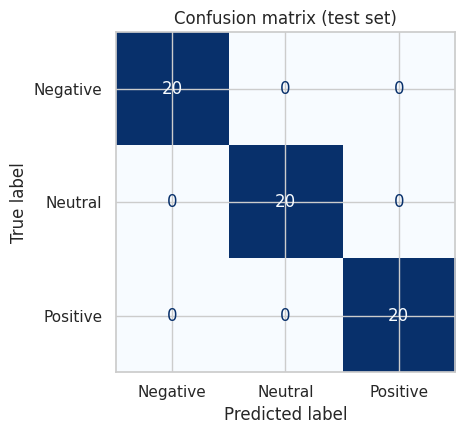

[[20  0  0]
 [ 0 20  0]
 [ 0  0 20]]


In [27]:
fig = plot_confusion_matrix(result["confusion_matrix"], VALID_LABELS)
plt.show()
print(result["confusion_matrix"])

**ROC / AUC.** For three classes we use the **One-vs-Rest** approach: each class is scored against the other two using the model's real probabilities. AUC = 1.0 means perfect ranking, 0.5 means random. Since the model has `predict_proba`, this is valid.

Macro one-vs-rest AUC: 1.0


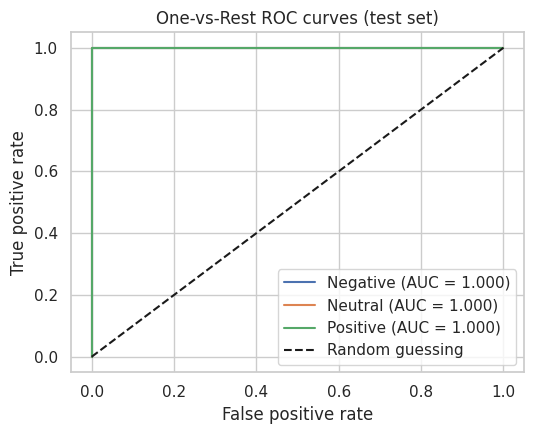

In [28]:
roc = multiclass_roc_auc(final_pipeline, X_test, y_test, VALID_LABELS)
if roc is None:
    print("Model has no predict_proba – ROC/AUC skipped.")
else:
    macro_auc, curves = roc
    print("Macro one-vs-rest AUC:", round(macro_auc, 4))
    plot_roc(curves); plt.show()

**Interpretation.** Read the numbers above together with the earlier warning: because every test sentence also occurs in the training reviews, a very high (even perfect) test score is expected on this synthetic-looking dataset. It confirms the pipeline works and there is no bug or leakage of *identical reviews*; it does **not** prove real-world performance. A small test set (60 reviews) also means each single mistake would change accuracy by about 1.7 percentage points.

### Sanity checks on new reviews
The first three examples are only sanity checks. We report whatever the model actually predicts (no forcing). The 4th–6th texts are extra probes for negation and out-of-domain wording.

In [29]:
tests = ["The product is excellent. I love the quality and would definitely buy it again.",
         "The product is terrible and stopped working after two days.",
         "The package contains the product, charger, and instruction manual.",
         "I would not recommend it, it wasn't good.",
         "Not bad at all, actually quite nice!",
         "zzz qqq xyz"]
proba = final_pipeline.predict_proba(tests)
out = pd.DataFrame(proba, columns=final_pipeline.classes_).round(3)
out.insert(0, "Predicted", final_pipeline.predict(tests))
out.insert(0, "Review", tests)
out

,Review,Predicted,Negative,Neutral,Positive
0,The product is excellent. I love the quality and would definitely buy it again.,Positive,0.294,0.163,0.543
1,The product is terrible and stopped working after two days.,Negative,0.447,0.316,0.237
2,"The package contains the product, charger, and instruction manual.",Neutral,0.213,0.598,0.189
3,"I would not recommend it, it wasn't good.",Negative,0.678,0.083,0.239
4,"Not bad at all, actually quite nice!",Negative,0.730,0.179,0.091
5,zzz qqq xyz,Neutral,0.319,0.361,0.320


**How to read this:** the 1st–3rd rows come from the same kind of language as the training data. Rows 4–6 are *outside* what the model has seen (different wording, nonsense words), so they are much less trustworthy. Look at row 5: 'Not bad at all, actually quite nice!' is really positive, but the model's prediction is driven by the word *bad* and the model has not learned that 'not bad' is positive, because that phrase never occurs in the training data. For the nonsense text (row 6) no known words are present, so the probabilities are close to equal. These failures illustrate the limitation of training on only 300 distinct sentences.

## 17. Final conclusions
* The dataset is balanced but contains only **300 unique review texts** repeated 10,000 times. We therefore de-duplicated by text before splitting so identical reviews cannot appear in both train and test.
* Light preprocessing (lowercase, URL/punctuation removal, apostrophes kept) was applied; stop-words, stemming and lemmatization were deliberately **not** used so negations are preserved.
* TF-IDF (with optional bigrams) inside a `Pipeline` was compared against a Bag-of-Words baseline; three classifiers were compared with 5-fold stratified CV and tuned with `GridSearchCV` on training data only.
* The candidates were essentially tied; **Logistic Regression** was selected for its real probabilities and interpretability (rule based on CV only). Exact numbers are in the cells above.
* The final test result must be read with the overlap limitation in mind (section 8).
* **Limitations / future work:** collect real, diverse reviews; add a larger test set from a different source; try character n-grams for spelling variation; handle sarcasm/mixed sentiment; calibrate probabilities; monitor with new data.

## 18. Save the final pipeline
One `Pipeline` object = text cleaning + TF-IDF + classifier. Saving it with `joblib` means the Streamlit app can load it and predict without retraining. A new review passes through exactly the same steps automatically.

In [30]:
model_path = ROOT / "models" / "sentiment_pipeline.pkl"
model_path.parent.mkdir(exist_ok=True)
joblib.dump(final_pipeline, model_path)
print("Saved:", model_path)

reloaded = joblib.load(model_path)
print("Reloaded steps:", [name for name, _ in reloaded.steps])
print("Same predictions as the in-memory pipeline:", (reloaded.predict(X_test) == final_pipeline.predict(X_test)).all())
print("Prediction for a new review:", reloaded.predict(["Great value, works perfectly."])[0])

Saved: /home/claude/sentiment-analysis/models/sentiment_pipeline.pkl
Reloaded steps: ['tfidf', 'clf']
Same predictions as the in-memory pipeline: True
Prediction for a new review: Positive
